# Case-Control Study: How Alzheimer's Disease Affects Gene Expression

This tutorial demonstrates causarray on a **case-control single-cell study**, showing that
the same doubly-robust framework used for perturb-seq also applies to observational
disease comparisons.

**Scientific question:** Which genes are differentially expressed in excitatory neurons of
AD-dementia donors compared to cognitively normal aging donors, after controlling for
inter-individual confounders?

> **Important framing:** The `tau` (log-fold change) estimates describe how gene expression
> differs *between* AD and normal donors — i.e. *how AD is associated with gene changes*.
> They do not imply that the gene changes *cause* AD.

**Dataset:** Seattle Alzheimer's Disease Brain Cell Atlas (SEA-AD), Middle Temporal Gyrus (MTG)  
([Gabitto et al. 2024, *Nature Neuroscience*](https://doi.org/10.1038/s41593-024-01774-5)) — freely available via [CellxGene Census](https://chanzuckerberg.github.io/cellxgene-census/), no login required.

**Pipeline:**
```
preprocess_sea_ad.py  →  sea_ad_mtg_exneu_pb.h5ad   (85 donors × 22 911 genes)
         |
         v  prep_causarray_data
      Y, A, X_cov
         |
         v  estimate_r  →  select r = 4 (JIC criterion)
         |
         v  fit_gcate   →  4 latent confounders U
         |
         v  LFC         →  doubly-robust log-fold changes per gene
```

In [14]:
import os
import numpy as np
import pandas as pd
import scipy.sparse as sp
import seaborn as sns
import matplotlib.pyplot as plt
import scanpy as sc

import causarray
print('causarray version:', causarray.__version__)
from causarray import prep_causarray_data, fit_gcate, LFC

causarray version: 0.0.6


## Why pseudo-bulk?

Single-cell RNA-seq data presents two practical challenges for case-control analysis:

1. **Scale**: A typical snRNA-seq study has millions of cells. Running a GLM on millions of rows
   is slow and, more importantly, the observational unit here is the *donor*, not the *cell*.

2. **Sparsity**: Each individual cell captures only a small fraction of its transcriptome
   (most entries are zero), making cell-level counts very noisy.

**Pseudo-bulking** solves both by summing raw counts across all cells from the same donor:

$$Y_{\text{donor},g} = \sum_{\text{cells of donor}} Y_{\text{cell},g}$$

The result is a *donor × gene* matrix of aggregated counts — comparable in structure
to bulk RNA-seq — where each row represents one biological replicate (one person).
This is the appropriate unit for causal inference about disease status.

> **Preprocessing note:** The pseudo-bulk file used here was created by `preprocess_sea_ad.py`
> (included in this directory). It downloads all 9 MTG excitatory-neuron subclasses from
> [CellxGene Census](https://chanzuckerberg.github.io/cellxgene-census/), subsamples
> **up to 300 cells per donor from the combined set**, sums counts per donor, and filters
> genes with `max(pseudo-bulk count) ≤ 10`.
>
> **⚠ Caution:** Keep the total cells per donor reasonable (~300) — summing thousands
> of cells inflates counts and can cause NB-GLM numerical issues. This tutorial and the
> paper both aggregate by donor only. If cell-type labels are available and the cohort
> is large, you can alternatively pseudo-bulk within each cell subtype per donor, which
> increases the effective sample size at the cost of a larger model.
>
> The core pseudo-bulk operation is just a grouped sum of the count matrix:
>
> ```python
> # Conceptual illustration (not run here — see preprocess_sea_ad.py)
> import anndata as ad, numpy as np, scipy.sparse as sp
> X = adata.X.toarray().astype(np.int32)   # cells × genes, raw integer counts
> donors = adata.obs['donor_id'].unique()
> X_pb = np.vstack([
>     X[adata.obs['donor_id'] == d].sum(axis=0)
>     for d in donors
> ])
> pb = ad.AnnData(X=sp.csr_matrix(X_pb), obs=..., var=adata.var)
> ```

## Load data

In [15]:
pb = sc.read_h5ad('sea_ad_mtg_exneu_pb.h5ad')
pb

AnnData object with n_obs × n_vars = 85 × 22911
    obs: 'sex', 'disease', 'self_reported_ethnicity', 'development_stage', 'n_cells', 'library_size', 'age', 'trt', 'sex_bin'
    var: 'feature_name'

In [16]:
# Donor-level metadata
pb.obs[['sex', 'disease', 'trt', 'age', 'n_cells', 'library_size']].head(10)

,sex,disease,trt,age,n_cells,library_size
donor_id,,,,,,
H19.33.004,female,normal,0,80.0,300,9262925
H21.33.019,male,normal,0,75.0,300,12793728
H21.33.004,male,normal,0,80.0,300,16071238
H21.33.017,female,dementia,1,80.0,300,6558591
H20.33.041,female,dementia,1,80.0,300,11428154
H20.33.015,male,dementia,1,88.0,300,13513747
H21.33.014,male,normal,0,80.0,300,12540262
H21.33.045,female,dementia,1,80.0,300,4951466
H21.33.026,female,normal,0,80.0,300,8192575


## Exploratory data analysis

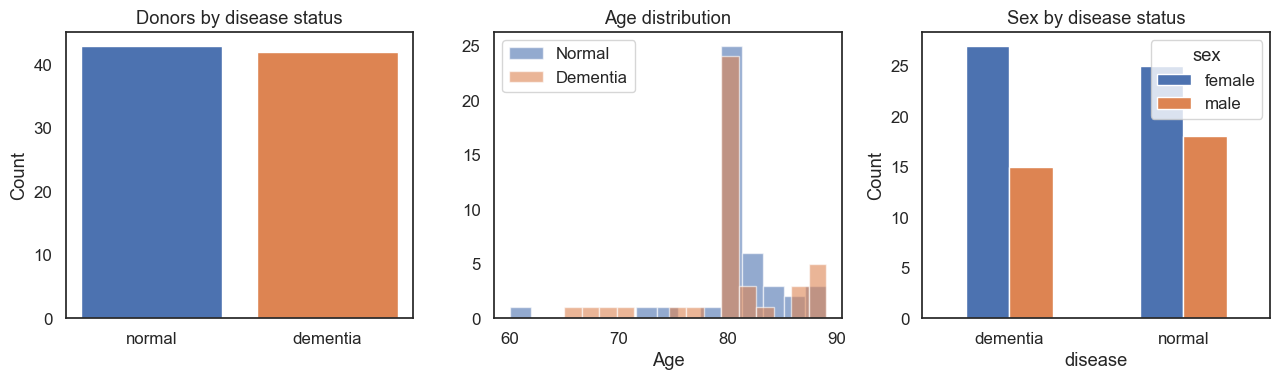

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# Case / control counts
counts = pb.obs['disease'].value_counts()
axes[0].bar(counts.index, counts.values, color=sns.color_palette()[:2])
axes[0].set_title('Donors by disease status')
axes[0].set_ylabel('Count')

# Age distribution
for trt, grp in pb.obs.groupby('trt'):
    label = 'Dementia' if trt == 1 else 'Normal'
    axes[1].hist(grp['age'], bins=15, alpha=0.6, label=label)
axes[1].set_xlabel('Age')
axes[1].set_title('Age distribution')
axes[1].legend()

# Sex distribution
sex_trt = pb.obs.groupby(['disease', 'sex']).size().unstack(fill_value=0)
sex_trt.plot(kind='bar', ax=axes[2], rot=0)
axes[2].set_title('Sex by disease status')
axes[2].set_ylabel('Count')

fig.tight_layout()
plt.show()

## Prepare causarray inputs

**Key difference from perturb-seq tutorials:** here `A` is a *single binary column*
(AD = 1, cognitively normal = 0), and `Y` is a *donor × gene* pseudo-bulk matrix
rather than a cell × gene matrix.

In [18]:
Y = pd.DataFrame(
    pb.X.toarray() if sp.issparse(pb.X) else pb.X,
    index=pb.obs.index,
    columns=pb.var_names,
)

# Treatment: 1 = AD/dementia, 0 = normal aging
A = pb.obs[['trt']].astype(float)

# Covariate: sex (binary)
X_cov = pb.obs[['sex_bin']]

# prep_causarray_data validates shapes, adds intercept column, returns arrays
Y, A, X_cov, X_A = prep_causarray_data(Y, A, X_cov)

print(f'Donors (n): {Y.shape[0]}   Genes (p): {Y.shape[1]}')

Donors (n): 85   Genes (p): 22911


## Number of latent factors

We estimate the number of unmeasured confounders *r* using the JIC criterion.
JIC is a penalised-likelihood score; the optimal *r* minimises it.

Unmeasured confounders in this study include post-mortem interval (PMI) effects,
inter-individual transcriptional variation, and technical batch effects.

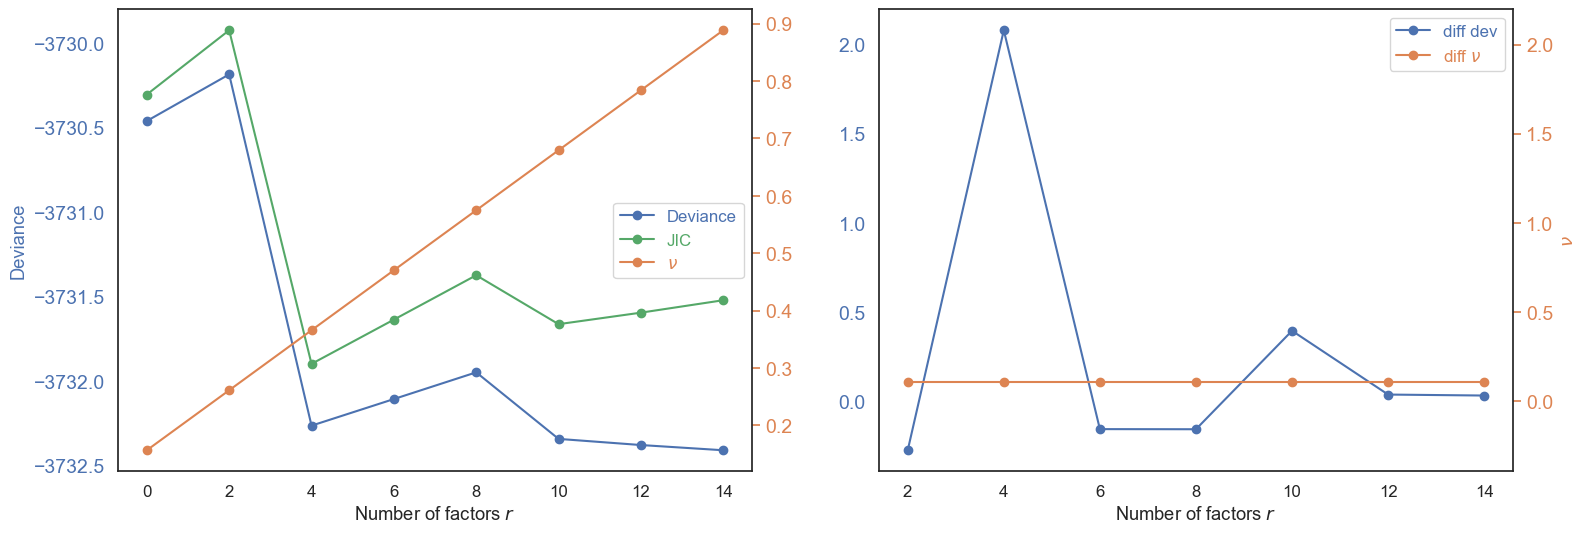

In [19]:
from causarray import estimate_r, plot_r

# Uncomment to recompute (takes ~5-10 min):
# df_r = estimate_r(Y, X_cov, A, np.arange(2, 16, 2))
# df_r.to_csv('sea_ad_r.csv', index=False)
df_r = pd.read_csv('sea_ad_r.csv')
fig = plot_r(df_r)

The JIC is stable from r=4 to r=14 with minimal penalty differences, indicating limited
unmeasured confounding after proper pseudo-bulk normalisation.
We select **r = 4** — the first minimum of the JIC curve.

## Estimate latent confounders (GCATE)

In [20]:
import pickle

_pkl = 'sea_ad_gcate.pkl'
if os.path.exists(_pkl):
    print(f'Loading pre-computed GCATE from {_pkl}')
    with open(_pkl, 'rb') as f:
        res_1, res_2 = pickle.load(f)
else:
    r = 4   # JIC-selected value; see estimate_r cell above
    res_1, res_2 = fit_gcate(Y, X_cov, A, r, offset=True, verbose=True)
    with open(_pkl, 'wb') as f:
        pickle.dump((res_1, res_2), f)

U = res_2['U']
print(f'Step 1 -- epochs: {res_1["n_iter"]},  best NLL: {min(res_1["hist"]):.6f}')
print(f'Step 2 -- epochs: {res_2["n_iter"]},  best NLL: {min(res_2["hist"]):.6f}')

Loading pre-computed GCATE from sea_ad_gcate.pkl
Step 1 -- epochs: 6,  best NLL: 4.762699
Step 2 -- epochs: 6,  best NLL: 4.788035


## Estimate log-fold changes

Each gene's `tau` is the doubly-robust estimate of how much its expression changes
(on the log scale) in AD relative to normal aging, after adjusting for sex and the
*r* latent confounders captured by GCATE.

In [21]:
# Use GCATE-internal size factors as log-scale offset (same normalization as GCATE fitting)
offsets = np.log(res_2['kwargs_glm']['size_factor'])

# Concatenate observed covariates with latent factors
W = np.c_[X_cov, U]

df_res, estimation = LFC(Y, W, A, W, offset=offsets, verbose=True)

'Estimating LFC...'
{'a': 1, 'd': 6, 'd_A': 6, 'estimands': 'LFC', 'n': 85, 'p': 22911}
{'C': 1.0,
 'class_weight': 'balanced',
 'fit_intercept': False,
 'random_state': 0,
 'verbose': False}
{'offset': array([-0.06330679,  0.36236182,  0.56863386, ...,  0.17991812,
        0.1505303 ,  0.4616399 ], shape=(85,)),
 'random_state': 0,
 'verbose': True}
'Fit propensity score models...'
'Fit outcome models...'
'Fitting nb GLM (fast)...'
'Estimating AIPW mean...'


In [22]:
# Collect results
results = df_res.copy()

n_rej_fdr = (results['padj'] < 0.1).sum()
print(f'FDR-controlled (BH, q<0.1): {n_rej_fdr}')
results.head()

FDR-controlled (BH, q<0.1): 3009


,gene_names,tau,std,stat,rej,pvalue,padj,pvalue_emp_null_adj,padj_emp_null_adj
0,LINC01409,0.048288,0.070912,0.680950,0.0,0.497849,0.766460,0.669584,0.997231
1,NOC2L,0.080213,0.051780,1.549118,0.0,0.125426,0.394128,0.321594,0.985858
2,ENSG00000272512,-0.265607,0.332934,-0.797777,0.0,0.427278,0.715232,0.589711,0.997231
3,HES4,-0.613675,0.219170,-2.799994,0.0,0.006364,0.062498,0.067277,0.673997
4,ISG15,-0.367666,0.199427,-1.843607,0.0,0.069170,0.281368,0.223589,0.933645


## Visualise results

Each point in the volcano plot is a gene. The x-axis shows `tau` — the estimated
log-fold change in expression associated with AD. The y-axis is statistical significance.
Genes to the right are up-regulated in AD; genes to the left are down-regulated.

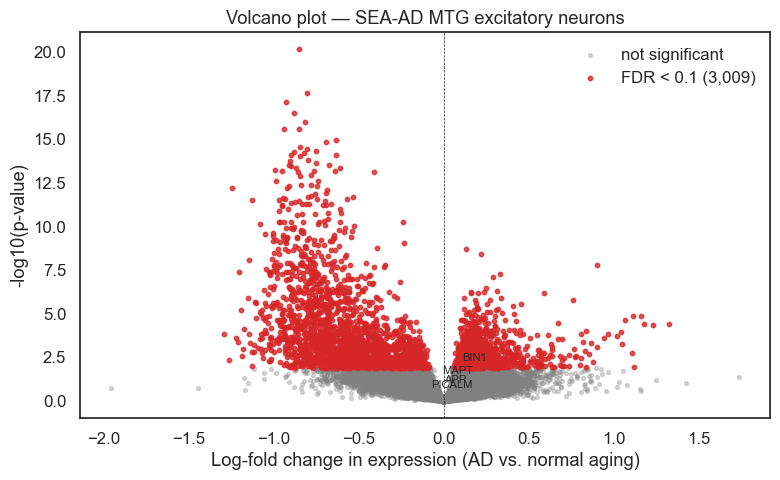

In [28]:
sns.set(font_scale=1.1, style='white')

fig, ax = plt.subplots(figsize=(8, 5))

# Colour by FDR significance
fdr_sig = results['padj'] < 0.1
ns  = results[~fdr_sig]
sig = results[fdr_sig]

ax.scatter(ns['tau'],  -np.log10(ns['pvalue']),  s=8,  alpha=0.3, color='gray',    label='not significant')
ax.scatter(sig['tau'], -np.log10(sig['pvalue']), s=10, alpha=0.8, color='tab:red', label=f'FDR < 0.1 ({len(sig):,})')

# Annotate selected neuronal genes with known AD relevance
annot_genes = ['BIN1', 'APP', 'MAPT', 'PICALM']
for gene in annot_genes:
    row = results[results['gene_names'] == gene]
    if len(row):
        ax.annotate(gene, xy=(row['tau'].values[0], -np.log10(row['pvalue'].values[0])),
                    fontsize=8, ha='center', va='bottom')

ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
ax.set_xlabel('Log-fold change in expression (AD vs. normal aging)')
ax.set_ylabel('-log10(p-value)')
ax.set_title('Volcano plot — SEA-AD MTG excitatory neurons')
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

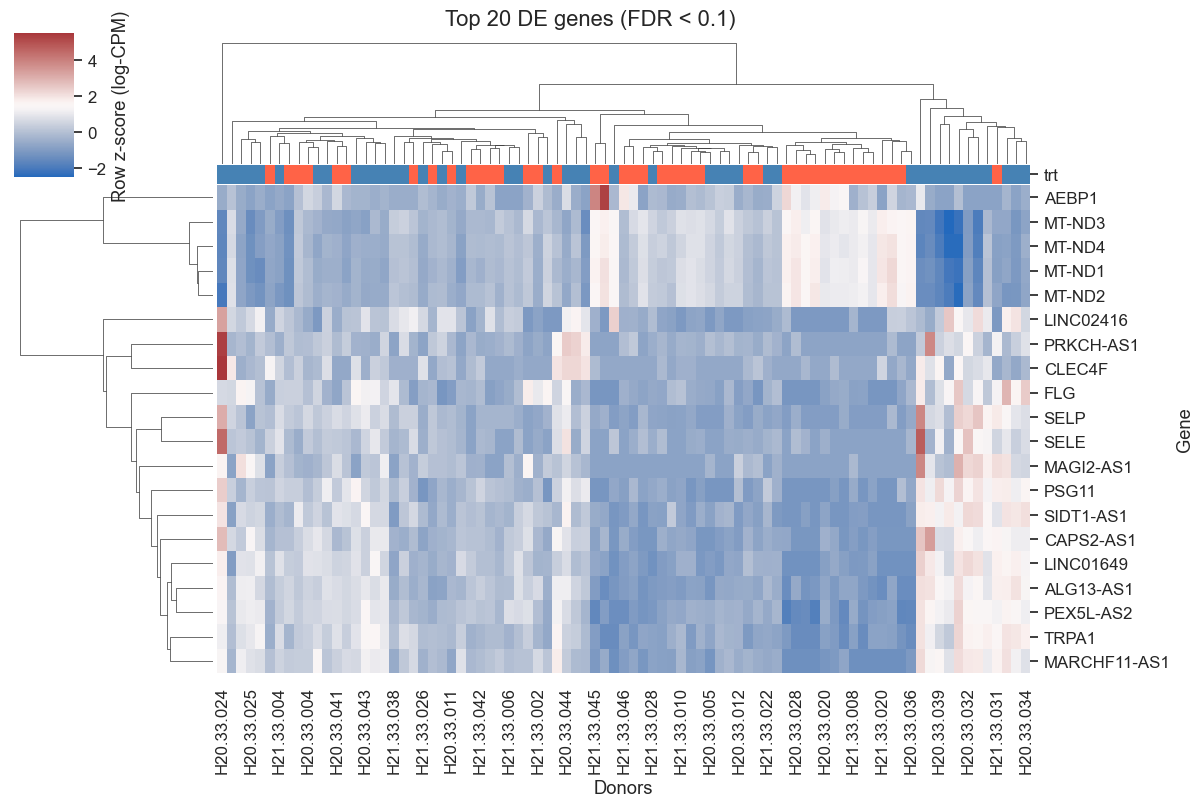

In [29]:
# Top 20 FDR-significant genes by |tau|, excluding unannotated ENSG-only entries
top_genes = (
    results[results['padj'] < 0.1]
    .assign(abs_tau=lambda d: d['tau'].abs())
    .loc[~results['gene_names'].str.startswith('ENSG')]
    .nlargest(20, 'abs_tau')['gene_names']
    .tolist()
)

if top_genes:
    X_top = pb[:, pb.var_names.isin(top_genes)].X
    if sp.issparse(X_top):
        X_top = X_top.toarray()

    # Log-CPM for display
    lib = pb.obs['library_size'].values[:, None]
    log_cpm = np.log1p(X_top / lib * 1e6)

    df_heat = pd.DataFrame(log_cpm, index=pb.obs_names,
                           columns=pb.var_names[pb.var_names.isin(top_genes)])
    row_colors = pb.obs['trt'].map({0: 'steelblue', 1: 'tomato'})

    g = sns.clustermap(df_heat.T, col_colors=row_colors,
                       cmap='vlag', figsize=(12, 8), z_score=0,
                       cbar_kws={'label': 'Row z-score (log-CPM)'})
    g.ax_heatmap.set_xlabel('Donors')
    g.ax_heatmap.set_ylabel('Gene')
    plt.suptitle('Top 20 DE genes (FDR < 0.1)', y=1.01)
    plt.show()
else:
    print('No FDR-significant genes found — consider increasing alpha or checking r selection.')

## Summary

causarray estimates **how gene expression changes** in excitatory-neuron pseudo-bulk profiles, contrasting AD and non-AD donors after adjustment for sex, age at death, postmortem interval, and estimated latent factors capturing residual donor-level technical/biological variation.

The strongest signals include mitochondrial Complex I genes and synaptic/neuropeptide-related genes that are consistent across the ROSMAP and SEA-AD analyses in the paper.

Canonical AD GWAS genes such as *APOE*, *CLU*, and *TREM2* are not ideal positive controls in this excitatory-neuron analysis, because their dominant disease-associated expression is expected in glial populations, especially astrocytes and microglia.

Key takeaway: for case-control pseudo-bulk data, use donor-level aggregates, replace the perturbation matrix with a disease-status indicator, include donor-level covariates, estimate latent confounders, and apply the same counterfactual LFC/inference pipeline.
